# Import Required Libraries

Import necessary libraries such as NumPy, PIL, Torch, and the FPIInference model.

In [2]:
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Import the FPIInference model
from fpi_model import FPIInference

c:\Users\roman\miniconda3\envs\geoloc2\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\roman\OneDrive\Документы\GitHub\satellite-geolocation\for_us\models\Backbone\cvt.py:553: SyntaxWarning: "is" with a literal. Did you mean "=="?
  or pretrained_layers[0] is '*'
c:\Users\roman\miniconda3\envs\geoloc2\lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
c:\Users\roman\miniconda3\envs\geoloc2\lib\site-packages\timm\models\helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated,

# Load the Model from fpi_model

Load the pre-trained FPI model using the FPIInference class. You need to provide paths to the config and checkpoint files.

In [6]:
# Paths to config and checkpoint (adjust as needed)
config_path = 'example_config.py'
checkpoint_path = 'checkpoints/CvT-13-384x384-IN-22k.pth'

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize the model
fpi_model = FPIInference(config_path, checkpoint_path, device=device)
print("Model loaded successfully!")

Load pretrained backbone checkpoint from: checkpoints/CvT-13-384x384-IN-22k.pth
missing keys: []
unexpected keys: []
Model loaded successfully!


c:\Users\roman\miniconda3\envs\geoloc2\lib\site-packages\torchvision\transforms\transforms.py:287: UserWarning: Argument interpolation should be of type InterpolationMode instead of int. Please, use InterpolationMode enum.
  warnings.warn(


# Prepare Input Data

Load UAV and satellite images. For demonstration, we'll use placeholder images or load from files.

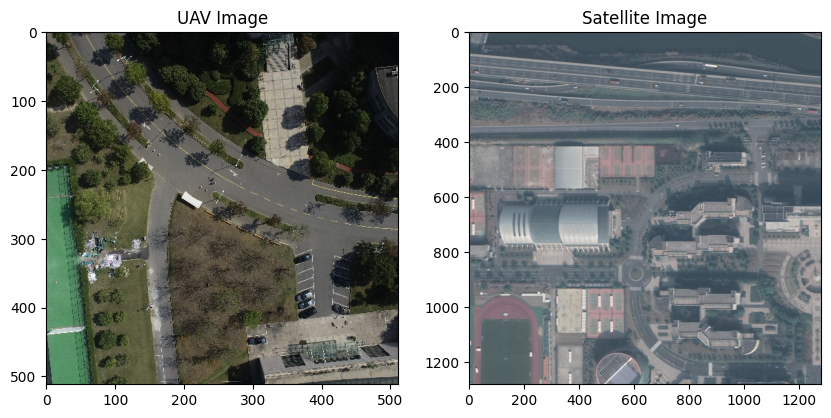

In [7]:
# For demonstration, load sample images
# Replace with actual paths to UAV and satellite images
uav_image_path = r'C:\Users\roman\OneDrive\Документы\GitHub\satellite-geolocation\DRL\map2019\train\Caijing_000000\UAV\0.JPG'  # Example path
satellite_image_path = r'C:\Users\roman\OneDrive\Документы\GitHub\satellite-geolocation\DRL\map2019\train\Caijing_000000\Satellite\0.tif'  # Example path

# Load images
uav_image = Image.open(uav_image_path)
satellite_image = Image.open(satellite_image_path)

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(uav_image)
plt.title('UAV Image')
plt.subplot(1, 2, 2)
plt.imshow(satellite_image)
plt.title('Satellite Image')
plt.show()

# Run Model Inference

Use the loaded model to predict the pixel coordinates on the satellite image corresponding to the UAV image.

In [8]:
# Run prediction
result = fpi_model.predict(uav_image, satellite_image, return_heatmap=True)

# Extract results
pixel_coord = result['pixel_coordinate']
pixel_norm = result['pixel_normalized']
heatmap = result['heatmap']

print(f"Predicted pixel coordinate: {pixel_coord}")
print(f"Normalized coordinate: {pixel_norm}")

Predicted pixel coordinate: (476, 436)
Normalized coordinate: (0.8263888888888888, 0.7569444444444444)


# Display and Analyze Results

Visualize the heatmap overlay on the satellite image and analyze the prediction.

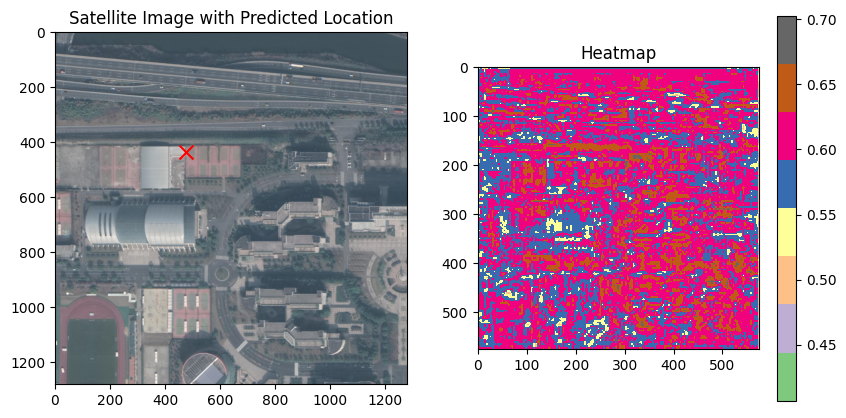

Analysis: The red X marks the predicted location of the UAV object on the satellite image.


In [12]:
# Visualize the heatmap
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(satellite_image)
plt.scatter(pixel_coord[0], pixel_coord[1], color='red', s=100, marker='x')
plt.title('Satellite Image with Predicted Location')

plt.subplot(1, 2, 2)
plt.imshow(heatmap, cmap='Accent')
plt.title('Heatmap')
plt.colorbar()
plt.show()

# Additional analysis
print("Analysis: The red X marks the predicted location of the UAV object on the satellite image.")

Да работает херово, но автор не прикрепил походу только часть весов 🤡🤡🤡, так что если Блек выделит компьют, то возможно что-то получится